# AdPilot Egyptian Real Estate Market Intelligence

End-to-end, standalone analysis of Egyptian property listings: data inspection, approved and delegated cleaning decisions, EDA, market tiers, fair-price modeling, explainability, and dashboard-ready exports.

**Important:** This notebook predicts asking-price positioning, not completed transaction value or a certified appraisal. AdPilot schema integration is intentionally postponed.

## 1. Environment and reproducibility

The pipeline preserves raw data, uses deterministic seeds, writes every exclusion to an audit dataset, and keeps the final test set untouched until model selection is complete.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.pipeline import run_pipeline
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Project root:", ROOT)

Project root: /mnt/data/adpilot_real_estate_intelligence


## 2. Execute the preparation, EDA, and model pipeline

Set `RETRAIN_MODELS=True` to reproduce training, validation comparison, grouped cross-validation, final refitting, test evaluation, SHAP outputs, and dashboard datasets. Set it to `False` to reuse the bundled model for a faster rerun.

In [2]:
RETRAIN_MODELS = False
result = run_pipeline(ROOT, retrain=RETRAIN_MODELS)
print("Pipeline completed.")
display(pd.DataFrame(result["comparison"]))

2026-06-13 15:47:22,796 | INFO | Preparing analytical data


2026-06-13 15:47:25,262 | INFO | Prepared 18,053 analytical rows


2026-06-13 15:47:27,971 | INFO | Pipeline complete


Pipeline completed.


,Model,Validation MAE,Validation RMSE,Validation R2,Median absolute error,Validation MAPE,Training seconds,Prediction seconds,Explainability,Deployment complexity,Main strengths,Main weaknesses
0,Random Forest,7.841039e+06,2.325760e+07,0.504511,2.711064e+06,0.482299,1.068514,0.057350,Medium,High,Captures nonlinearities and interactions,Large model and weaker extrapolation
1,Ridge,8.070168e+06,2.472876e+07,0.439844,2.896385e+06,0.557971,6.926591,0.104447,High,Medium,"Stable, fast, interpretable linear benchmark",Limited nonlinear interaction capture
2,CatBoost,8.331789e+06,2.532871e+07,0.412334,2.544900e+06,0.422416,6.326482,0.047850,Medium,Medium,Strong native handling of high-cardinality cat...,More complex deployment and explanation than l...
3,Median baseline,1.065178e+07,2.922192e+07,0.217793,3.837336e+06,0.804563,0.005016,0.001412,High,Low,Transparent and robust location/property-type ...,Cannot model nonlinear interactions or unit ch...


## 3. Prepared analytical dataset

The scope is restricted to sale listings in EGP for apartments, villas, townhouses, duplexes, chalets, and twin houses. Excluded records remain recoverable in the audit files.

In [3]:
market = pd.read_parquet(ROOT / "data/dashboard/market_listings.parquet")
prep = json.loads((ROOT / "reports/data_preparation_summary.json").read_text(encoding="utf-8"))
print(f"Analytical shape: {market.shape[0]:,} rows × {market.shape[1]} columns")
display(pd.Series(prep, name="value").to_frame())
display(market.head())

Analytical shape: 18,053 rows × 43 columns


,value
source_rows_after_d007,38774
final_analytical_rows,18053
excluded_rows_total,20721
recovered_area_rows,1204
selected_property_types,"[Apartment, Villa, Townhouse, Duplex, Chalet, ..."
price_target,log_price
price_tier_method,0.60 global price/sqm percentile + 0.40 within...
developer_analysis_status,Unavailable: no explicit developer field in so...


,listing_id,detail_url,property_type,market_region,town,district,submarket_or_compound,lat,lon,bedrooms_num,bathrooms_num,area_sqm,area_original,area_recovery_source,price_egp,price_per_sqm,furnished,payment_method,completion_status,listing_level,listed_date,listing_age_days,amenities_count,images_count,is_premium,is_featured,has_view_360,new_city_indicator,compound_status,luxury_location_indicator,market_tier,tier_score,split_group,title,predicted_fair_price,lower_fair_price,upper_fair_price,predicted_fair_price_per_sqm,actual_vs_fair_pct,pricing_status,model_support_count,out_of_distribution_flags,model_confidence
0,F7QB31CGWE509V2W7DF2GARB2C,https://www.propertyfinder.eg/en/plp/buy/duple...,Duplex,Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.040602,31.525942,3.0,6.0,445.0,445.0,original,24500000.0,55056.179775,Unknown,cash,completed,premium,2026-03-03T19:15:06Z,0.795455,16,6,1,0,0,New city,Broad/standalone,Top-quartile town,Mid-market,0.494471,area::New Cairo City::The 5th Settlement,Garden Villa - Lake View Boutique - Prime Loca...,2.086135e+07,1.079879e+07,5.439062e+07,46879.443401,0.174421,Fairly priced,253,0,High
1,K1JC3D6N57ED52N3VX1QQKHHXG,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Giza,Sheikh Zayed City,Sheikh Zayed Compounds,Village West,30.048094,31.020054,2.0,2.0,123.0,123.0,original,5145000.0,41829.268293,PARTLY,cash,off_plan,premium,2026-03-04T11:24:23Z,0.122341,11,10,1,0,0,New city,Named submarket/compound,Other town,Mid-market,0.373833,compound::Village West,For Sale: Finished Apartment+ ACs in Village West,6.903599e+06,3.573620e+06,1.799936e+07,56126.824494,-0.254737,Fairly priced,1491,0,High
2,Q6GEB8T6PZTJGNNPWA5PX3JCWR,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.012272,31.579515,4.0,4.0,250.0,250.0,original,10800000.0,43200.000000,Unknown,cash,completed,premium,2026-03-04T14:03:51Z,0.011600,18,13,1,0,0,New city,Broad/standalone,Top-quartile town,Mid-market,0.314331,area::New Cairo City::The 5th Settlement,UnderMarket Price for Apt. 250 RTM PrimeLocation,1.394931e+07,7.220804e+06,3.636925e+07,55797.249521,-0.225768,Fairly priced,3473,0,High
3,PPH0852SAB266X6GSVATJP4F0M,https://www.propertyfinder.eg/en/plp/buy/apart...,Apartment,Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.026146,31.536974,2.0,2.0,136.0,136.0,original,10500000.0,77205.882353,YES,cash,completed,premium,2026-03-04T12:38:11Z,0.071091,18,11,1,0,0,New city,Broad/standalone,Top-quartile town,Upper-mid,0.701043,area::New Cairo City::The 5th Settlement,lowest price 2bds fullyfurnished @ lake view,1.276481e+07,6.607652e+06,3.328097e+07,93858.915133,-0.177426,Fairly priced,3473,0,High
4,QCSA4TNDEBBV7BNY8ANST3TB50,https://www.propertyfinder.eg/en/plp/buy/villa...,Villa,Cairo,New Cairo City,The 5th Settlement,5th Settlement Compounds,30.012272,31.579515,4.0,4.0,255.0,255.0,original,19500000.0,76470.588235,Unknown,cash,completed,premium,2026-03-03T09:45:41Z,1.190883,18,17,1,0,0,New city,Broad/standalone,Top-quartile town,Upper-mid,0.546787,area::New Cairo City::The 5th Settlement,Exclusive Type M with Lowest Price RTM in PNC,2.058577e+07,1.065614e+07,5.367212e+07,80728.513812,-0.052744,Fairly priced,1095,0,High


### Data-quality and exclusion audit

Every model-scope exclusion has an explicit reason. The raw CSV and the post-duplicate dataset are not overwritten.

In [4]:
exclusions = pd.read_csv(ROOT / "reports/tables/exclusion_summary.csv")
decisions = pd.read_csv(ROOT / "reports/decision_log.csv")
display(exclusions)
display(decisions.tail(12))

,reason,records
0,not_sale_listing,19324
1,property_type_out_of_scope,1106
2,probable_deposit_or_installment_amount,157
3,unrecovered_implausible_area,119
4,implausibly_high_total_price,8
5,implausibly_large_residential_area,4
6,implausibly_high_price_per_sqm,3


,Decision ID,Phase,Date or sequence number,Issue,Options presented,Recommended option,My selected option,Reason for the selection,Number of affected records,Implementation performed,Resulting dataset shape,Reversibility,Notes
7,D008,Phase 3,2026-06-13,Repeated references,Keep but do not use as unique identifier,Keep but do not use as unique identifier,A,Avoids destructive changes to broker-entered r...,0,Excluded `reference` from identifiers and mode...,"18,053 analytical rows",Fully reversible from raw and audit datasets,Autonomously selected after user delegated rem...
8,D009,Phase 3–8,2026-06-13,Analytical scope,"Sale, EGP, six residential types","Sale, EGP, six residential types",Recommended,Matches the stated business question,20721,Created scoped analytical dataset and audit ex...,"18,053 analytical rows",Fully reversible from raw and audit datasets,Autonomously selected after user delegated rem...
9,D010,Phase 6,2026-06-13,Suspicious area values,Recover explicit text area; otherwise exclude ...,Recover explicit text area; otherwise exclude ...,Recommended,Balances recovery and conservative validity,1204,"Added area_sqm, area_original, and recovery so...","18,053 analytical rows",Fully reversible from raw and audit datasets,Autonomously selected after user delegated rem...
10,D011,Phase 6,2026-06-13,Price anomalies,Exclude only extreme ppsqm/total and probable ...,Exclude only extreme ppsqm/total and probable ...,Recommended,Preserves legitimate luxury listings,See exclusion summary,Audit-safe anomaly exclusions,"18,053 analytical rows",Fully reversible from raw and audit datasets,Autonomously selected after user delegated rem...
11,D012,Phase 8,2026-06-13,Feature set,Deployment-time structured fields only,Deployment-time structured fields only,Recommended,Prevents text and target leakage,All model rows,Created numeric/categorical engineered features,"18,053 analytical rows",Fully reversible from raw and audit datasets,Autonomously selected after user delegated rem...
12,D013,Phase 11,2026-06-13,Market tiering,Hybrid absolute and segment-adjusted ppsqm per...,Hybrid absolute and segment-adjusted ppsqm per...,Recommended,Avoids location-only luxury labeling,All analytical rows,Created tier_score and market_tier,"18,053 analytical rows",Fully reversible from raw and audit datasets,Autonomously selected after user delegated rem...
13,D014,Phase 12,2026-06-13,Target,log(total price),log(total price),Recommended,Stable across skewed price distribution and di...,All analytical rows,Trained models on log_price,"18,053 analytical rows",Fully reversible from raw and audit datasets,Autonomously selected after user delegated rem...
14,D015,Phase 12,2026-06-13,Data split,Grouped compound or town+district split,Grouped compound or town+district split,Recommended,Reduces project leakage,All analytical rows,Created 70/15/15 grouped split,"18,053 analytical rows",Fully reversible from raw and audit datasets,Autonomously selected after user delegated rem...
15,D016,Phase 12–13,2026-06-13,Final model,CatBoost,CatBoost,Recommended,Validation-only business trade-off: Random For...,15314,Exported CatBoost model,"18,053 analytical rows",Fully reversible from raw and audit datasets,Autonomously selected after user delegated rem...
16,D017,Phase 15,2026-06-13,Fair price classification,90% empirical validation-residual interval,90% empirical validation-residual interval,Recommended,Avoids arbitrary percentage thresholds,2739,Under/fair/over classifications use interval b...,"18,053 analytical rows",Fully reversible from raw and audit datasets,Autonomously selected after user delegated rem...


## 4. Feature engineering

Key deployment-safe features include area, bedrooms, bathrooms, coordinates, listing age, amenity and image counts, normalized location fields, property type, furnishing, payment method, completion status, new-city status, and compound status.

Price-derived variables are used only for analysis and tiering—not as model inputs.

In [5]:
feature_preview = market.copy()
feature_preview["log_price"] = np.log(feature_preview["price_egp"])
feature_preview["bedrooms_per_100_sqm"] = feature_preview["bedrooms_num"] / feature_preview["area_sqm"] * 100
feature_preview["bathrooms_per_100_sqm"] = feature_preview["bathrooms_num"] / feature_preview["area_sqm"] * 100
engineered = [
    "price_per_sqm", "log_price", "bedrooms_per_100_sqm",
    "bathrooms_per_100_sqm", "listing_age_days", "amenities_count",
    "new_city_indicator", "compound_status", "luxury_location_indicator",
    "tier_score", "market_tier"
]
display(feature_preview[engineered].head())

,price_per_sqm,log_price,bedrooms_per_100_sqm,bathrooms_per_100_sqm,listing_age_days,amenities_count,new_city_indicator,compound_status,luxury_location_indicator,tier_score,market_tier
0,55056.179775,17.014184,0.674157,1.348315,0.795455,16,New city,Broad/standalone,Top-quartile town,0.494471,Mid-market
1,41829.268293,15.453536,1.626016,1.626016,0.122341,11,New city,Named submarket/compound,Other town,0.373833,Mid-market
2,43200.000000,16.195057,1.600000,1.600000,0.011600,18,New city,Broad/standalone,Top-quartile town,0.314331,Mid-market
3,77205.882353,16.166886,1.470588,1.470588,0.071091,18,New city,Broad/standalone,Top-quartile town,0.701043,Upper-mid
4,76470.588235,16.785925,1.568627,1.568627,1.190883,18,New city,Broad/standalone,Top-quartile town,0.546787,Upper-mid


## 5. Exploratory data analysis

The figures below show distributions and segment differences. Each interpretation should be read with sample size and listing-quality limitations in mind.

In [6]:
summary = pd.read_csv(ROOT / "reports/tables/summary_statistics.csv", index_col=0)
property_summary = pd.read_csv(ROOT / "reports/tables/property_type_summary.csv")
location_summary = pd.read_csv(ROOT / "reports/tables/location_summary.csv")
tier_summary = pd.read_csv(ROOT / "reports/tables/market_tier_summary.csv")
display(summary)
display(property_summary)
display(location_summary.head(20))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price_egp,18053.0,1.534659e+07,2.101270e+07,325000.0,1.100000e+06,2.500000e+06,5.419260e+06,9.290000e+06,1.750000e+07,4.605200e+07,1.000716e+08,4.420000e+08
area_sqm,18053.0,2.090549e+02,1.552177e+02,21.0,3.400000e+01,6.000000e+01,1.270000e+02,1.700000e+02,2.450000e+02,4.550000e+02,8.744800e+02,2.000000e+03
price_per_sqm,18053.0,6.953042e+04,4.874233e+04,5000.0,8.267965e+03,1.794871e+04,3.783784e+04,6.050542e+04,8.870968e+04,1.476930e+05,2.400000e+05,9.216667e+05
bedrooms_num,18053.0,3.046751e+00,1.212803e+00,0.0,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,7.000000e+00,7.000000e+00
bathrooms_num,18053.0,2.982828e+00,1.329094e+00,0.0,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,7.000000e+00,7.000000e+00


,property_type,listings,median_price,mean_price,median_price_per_sqm,median_area
0,Villa,3464,26500000.0,3.601273e+07,83333.333333,321.0
1,Twin House,845,22500000.0,2.503739e+07,82446.808511,286.0
2,Chalet,1530,8746473.5,1.008505e+07,80976.190476,112.0
3,Townhouse,1495,16800000.0,1.824064e+07,77777.777778,230.0
4,Duplex,616,12000000.0,1.321617e+07,52444.714382,240.0
5,Apartment,10103,6500000.0,7.948761e+06,48206.896552,150.0


,market_region,town,listings,median_price,mean_price,median_price_per_sqm,median_area,property_types
0,Cairo,New Cairo City,6030,11505300.0,1.926481e+07,64500.000000,190.0,6
1,Giza,Sheikh Zayed City,2833,8000000.0,1.319642e+07,56022.408964,180.0,5
2,Giza,6 October City,2466,9613860.5,1.494362e+07,56818.181818,201.0,5
3,Red Sea,Hurghada,1362,6591020.0,1.021126e+07,74056.404494,91.0,6
4,Cairo,Mostakbal City - Future City,670,6000000.0,7.180448e+06,36391.827692,162.0,6
5,Cairo,New Capital City,592,6616534.0,1.162483e+07,43215.675459,176.5,5
6,Suez,Al Ain Al Sokhna,442,7347500.0,8.335038e+06,65188.888889,120.0,6
7,North Coast,Ras Al Hekma,438,10481500.0,1.477044e+07,90535.291069,125.0,6
8,North Coast,Sidi Abdel Rahman,370,18000000.0,3.044048e+07,118846.365639,170.0,6
9,Cairo,Shorouk City,359,8000000.0,1.031254e+07,45267.489712,195.0,5


### Price distribution

**What it shows:** Asking prices are strongly right-skewed.  
**Why it matters:** Median and log-scale summaries are more representative than the mean alone.  
**Action:** Segment campaigns and budget expectations by property type and location.  
**Caution:** These are asking prices, not transaction prices.

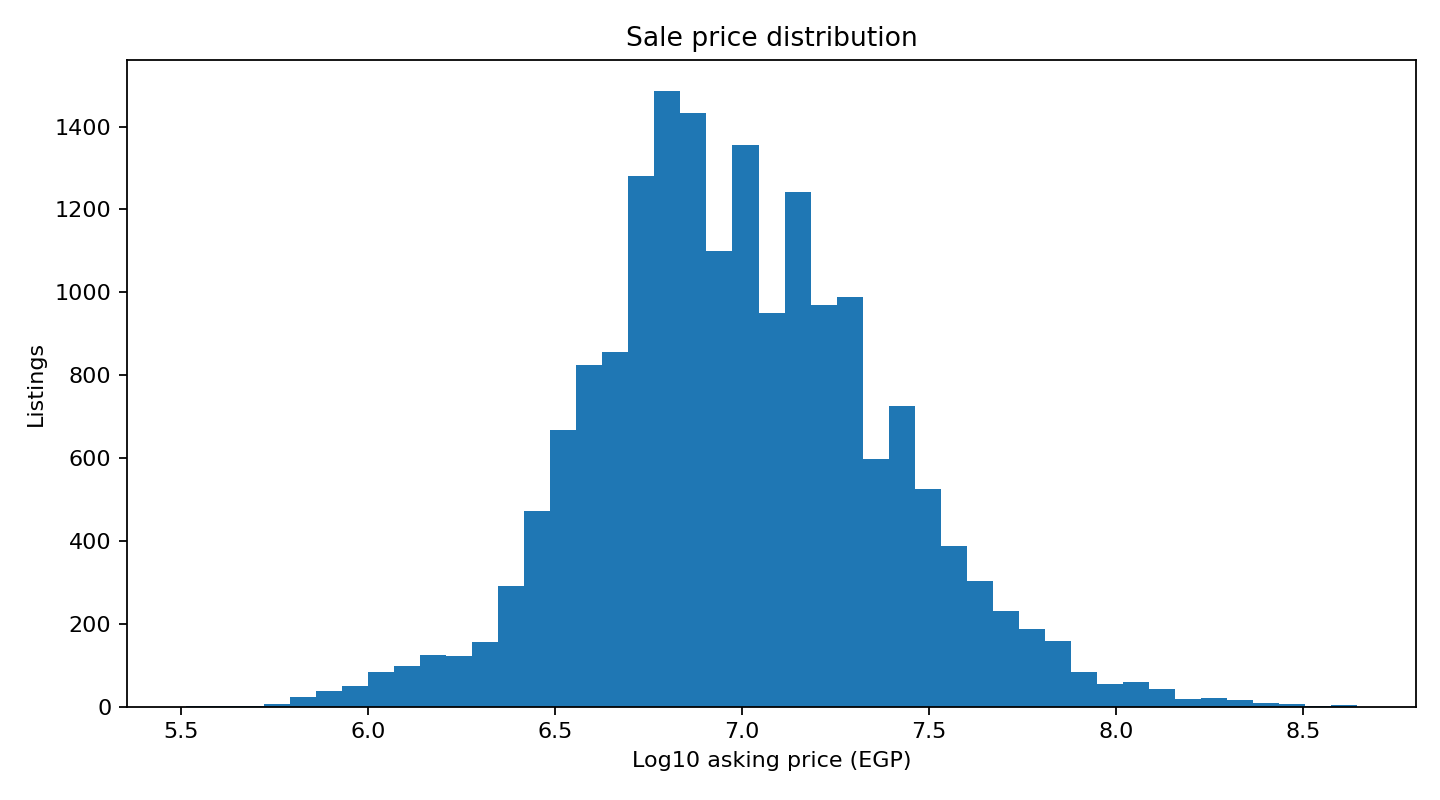

In [7]:
display(Image(filename=str(ROOT / "reports/figures/price_distribution_log.png")))

### Price per square metre by property type

**Strongest insight:** Villas have the highest observed median EGP/sqm in the cleaned sample.  
**Action:** Use property-type-specific benchmarks rather than one national threshold.  
**Caution:** Location and project mix differ across property types.

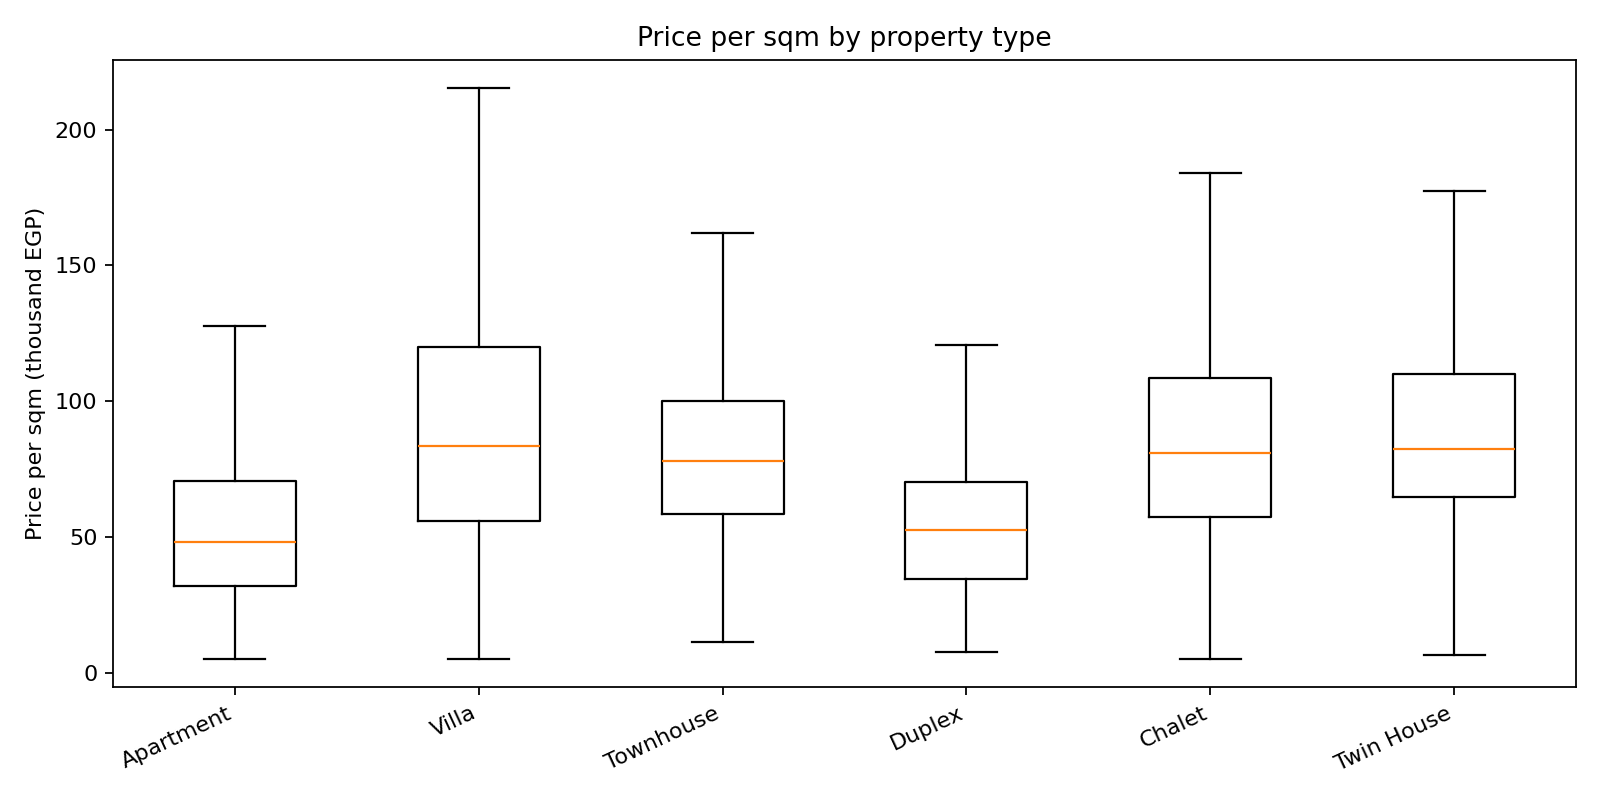

In [8]:
display(Image(filename=str(ROOT / "reports/figures/ppsqm_by_property_type.png")))

### Location intelligence

**Strongest insight:** Sidi Abdel Rahman is the highest-priced town among locations with at least 50 usable records.  
**Action:** Compare locations using both EGP/sqm and sample size.  
**Caution:** Broad marketing regions and formal administrative areas are mixed in the source.

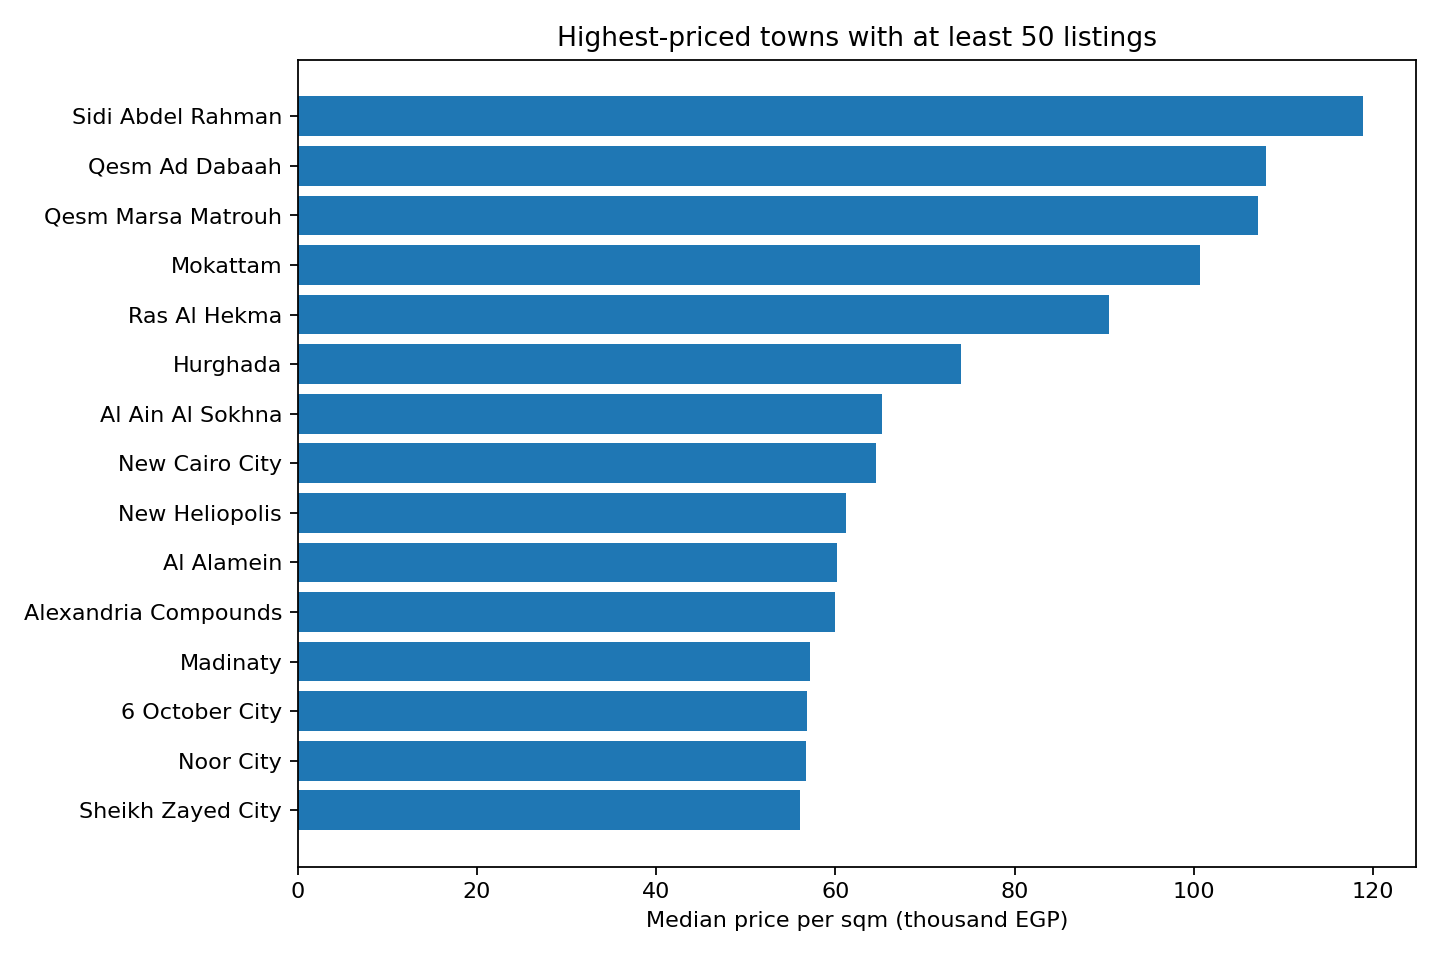

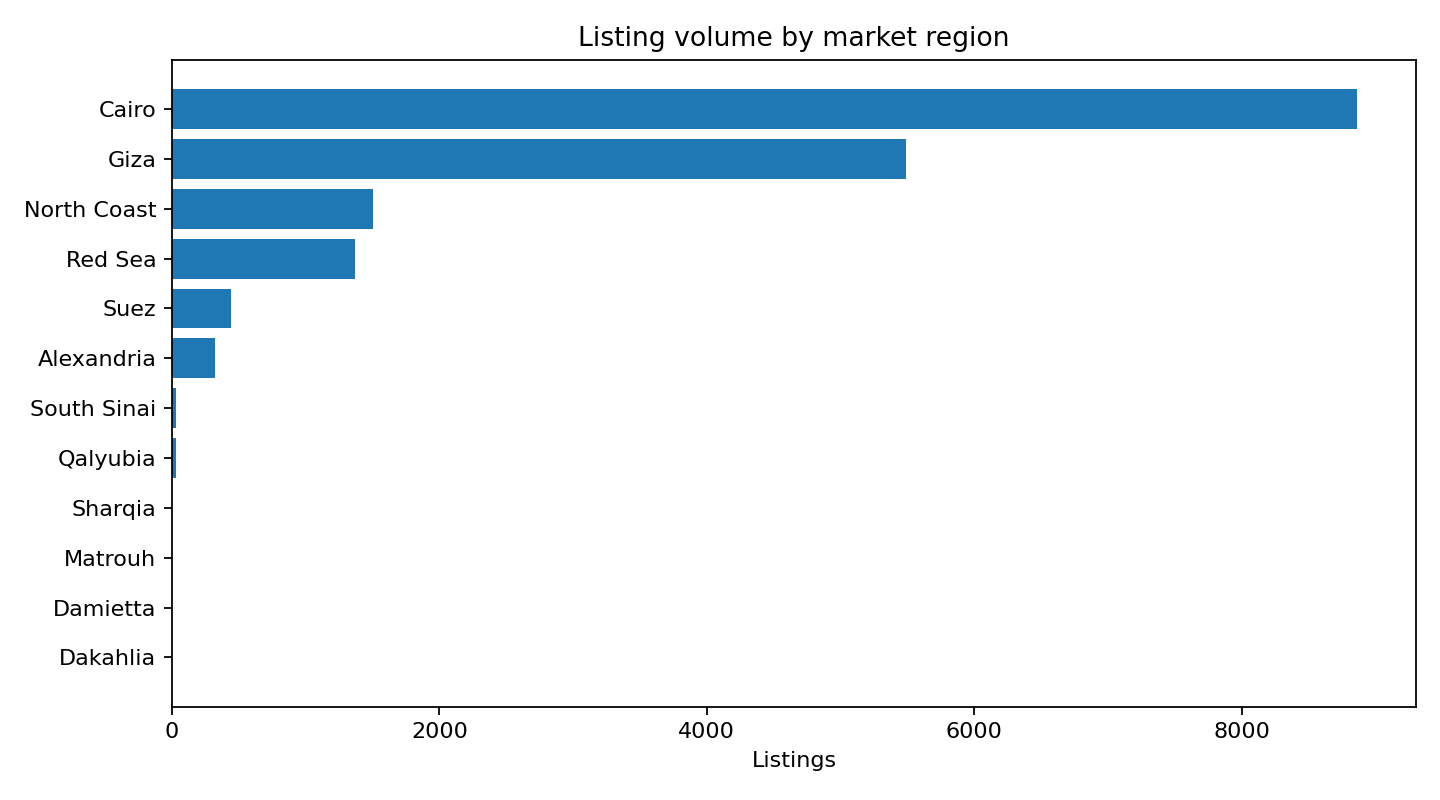

In [9]:
display(Image(filename=str(ROOT / "reports/figures/median_ppsqm_by_town.png")))
display(Image(filename=str(ROOT / "reports/figures/listing_count_by_region.png")))

## 6. Market-tier design

The tier score combines 60% global EGP/sqm percentile and 40% percentile within town/property type. Segments below 30 records fall back to market-region/property-type percentiles. This preserves absolute market positioning while reducing the chance that every listing in an expensive location is automatically labeled luxury.

,market_tier,listings,median_price,median_price_per_sqm,median_area,share
0,Affordable,4073,4134000.0,25477.707006,170.0,0.225613
1,Mid-market,4960,7500000.0,48566.289825,167.0,0.274747
2,Upper-mid,4881,12380000.0,73414.285714,175.0,0.270371
3,Luxury,4139,19000000.0,115555.555556,174.0,0.229269


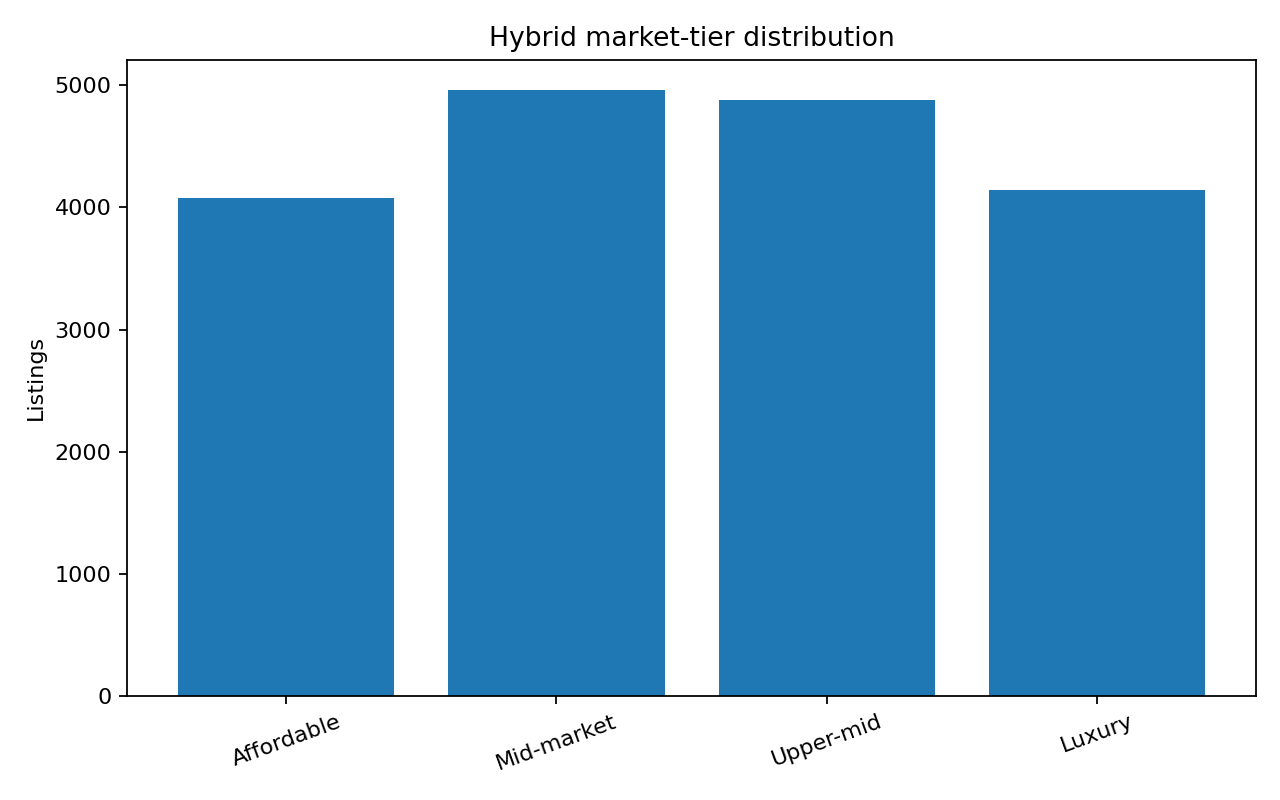

In [10]:
display(tier_summary)
display(Image(filename=str(ROOT / "reports/figures/market_tier_distribution.png")))

## 7. Preliminary model design and leakage controls

- Target: `log(price_egp)`, converted back to EGP for evaluation.
- Grouped split: named submarket/compound, otherwise town + district.
- Excluded predictors: price-derived fields, listing text, IDs, URLs, references, agent/broker/contact identifiers.
- Model selection uses validation results; the test set is evaluated once after final refitting.

In [11]:
comparison = pd.read_csv(ROOT / "reports/tables/model_comparison.csv")
cv = pd.read_csv(ROOT / "reports/tables/cross_validation_results.csv")
meta = json.loads((ROOT / "models/metadata/model_metadata.json").read_text(encoding="utf-8"))
display(comparison)
display(cv)
print(meta["selection_basis"])

,Model,Validation MAE,Validation RMSE,Validation R2,Median absolute error,Validation MAPE,Training seconds,Prediction seconds,Explainability,Deployment complexity,Main strengths,Main weaknesses
0,Random Forest,7.841039e+06,2.325760e+07,0.504511,2.711064e+06,0.482299,1.068514,0.057350,Medium,High,Captures nonlinearities and interactions,Large model and weaker extrapolation
1,Ridge,8.070168e+06,2.472876e+07,0.439844,2.896385e+06,0.557971,6.926591,0.104447,High,Medium,"Stable, fast, interpretable linear benchmark",Limited nonlinear interaction capture
2,CatBoost,8.331789e+06,2.532871e+07,0.412334,2.544900e+06,0.422416,6.326482,0.047850,Medium,Medium,Strong native handling of high-cardinality cat...,More complex deployment and explanation than l...
3,Median baseline,1.065178e+07,2.922192e+07,0.217793,3.837336e+06,0.804563,0.005016,0.001412,High,Low,Transparent and robust location/property-type ...,Cannot model nonlinear interactions or unit ch...


,model,fold,MAE_EGP,RMSE_EGP,R2,MedianAE_EGP,MAPE,sMAPE
0,Median baseline,1,7.978896e+06,1.634959e+07,-0.019535,3.960000e+06,0.766053,0.506823
1,CatBoost,1,5.965212e+06,1.137182e+07,0.506772,3.045398e+06,0.410540,0.418146
2,Median baseline,2,8.912577e+06,2.224078e+07,0.176088,3.751068e+06,0.764490,0.528633
3,CatBoost,2,6.481016e+06,1.818050e+07,0.449456,2.536542e+06,0.432698,0.389455


Validation-only business trade-off: Random Forest had the lowest MAE/RMSE, while CatBoost had lower median absolute error and MAPE and safer native handling of high-cardinality categorical inputs. CatBoost was selected without using test performance.


### Model-selection interpretation

Random Forest achieved the lowest validation MAE and RMSE. CatBoost achieved lower validation median absolute error and MAPE, and it handles high-cardinality categorical values natively. CatBoost was therefore selected as the deployment model as a documented business trade-off—not because of test performance.

## 8. Untouched test evaluation

Business-facing errors are reported in EGP. The empirical fair-price interval is calibrated from validation residuals.

,test metric
MAE_EGP,5.798372e+06
RMSE_EGP,1.661396e+07
R2,4.457757e-01
MedianAE_EGP,2.186439e+06
MAPE,3.429511e-01
sMAPE,3.567648e-01


,listing_id,property_type,market_region,town,district,submarket_or_compound,area_sqm,bedrooms_num,bathrooms_num,price_egp,price_per_sqm,market_tier,predicted_fair_price,lower_fair_price,upper_fair_price,absolute_error,absolute_percentage_error,pricing_status
1728,ZDPND3JVR2FGE6MKFV7KX5S5Y8,Villa,North Coast,Sidi Abdel Rahman,Marassi,Unknown,552.0,5.0,5.0,442000000.0,800724.637681,Luxury,3.734728e+07,1.933266e+07,9.737345e+07,4.046527e+08,0.915504,Overpriced
1729,1QPHVVTCKFC4WTWTM7871YSWAG,Villa,North Coast,Sidi Abdel Rahman,Marassi,Unknown,552.0,5.0,5.0,442000000.0,800724.637681,Luxury,3.952438e+07,2.045963e+07,1.030497e+08,4.024756e+08,0.910578,Overpriced
997,0NH9FYM4D9SDYTXJWYQGSM018M,Villa,North Coast,Sidi Abdel Rahman,Marassi,Unknown,950.0,6.0,7.0,260000000.0,273684.210526,Luxury,8.197936e+07,4.243628e+07,2.137402e+08,1.780206e+08,0.684695,Overpriced
661,RVEB66XYANX3AQ6NE0VAVMCW80,Villa,North Coast,Sidi Abdel Rahman,Marassi,Unknown,696.0,6.0,6.0,215000000.0,308908.045977,Luxury,5.570017e+07,2.883296e+07,1.452239e+08,1.592998e+08,0.740929,Overpriced
733,WH6R6YERPM57AKRXKN9CRMKX80,Villa,North Coast,Sidi Abdel Rahman,Hacienda White,Unknown,500.0,5.0,7.0,200000000.0,400000.000000,Luxury,5.754369e+07,2.978725e+07,1.500304e+08,1.424563e+08,0.712282,Overpriced
1610,CVFT2B2F7R80WVGDSZC9ANT6T0,Villa,Cairo,Mokattam,Uptown Cairo,Reyna,1300.0,6.0,6.0,234000000.0,180000.000000,Luxury,9.877043e+07,5.112810e+07,2.575185e+08,1.352296e+08,0.577904,Fairly priced
1798,EPGMK7ZJBMPGR8NS900357SHJG,Villa,Cairo,New Cairo City,The 1st Settlement,Mirage City,1050.0,7.0,7.0,195000000.0,185714.285714,Luxury,8.062915e+07,4.173735e+07,2.102198e+08,1.143708e+08,0.586517,Fairly priced
2439,GVNE1Z519944H6DY95DSE0RMA0,Villa,Cairo,New Cairo City,The 1st Settlement,Mirage City,1100.0,5.0,7.0,190000000.0,172727.272727,Luxury,8.025838e+07,4.154542e+07,2.092531e+08,1.097416e+08,0.577587,Fairly priced
1075,4JZW52EV63MA0YC224WCBCBMVC,Villa,North Coast,Sidi Abdel Rahman,Marassi,Unknown,240.0,5.0,4.0,120000000.0,500000.000000,Luxury,2.611627e+07,1.351898e+07,6.809147e+07,9.388373e+07,0.782364,Overpriced
667,GMA0QV32RZTPPWBTBPCF08Z7GR,Villa,North Coast,Sidi Abdel Rahman,Marassi,Unknown,1200.0,7.0,7.0,190000000.0,158333.333333,Luxury,9.936789e+07,5.143737e+07,2.590763e+08,9.063211e+07,0.477011,Fairly priced


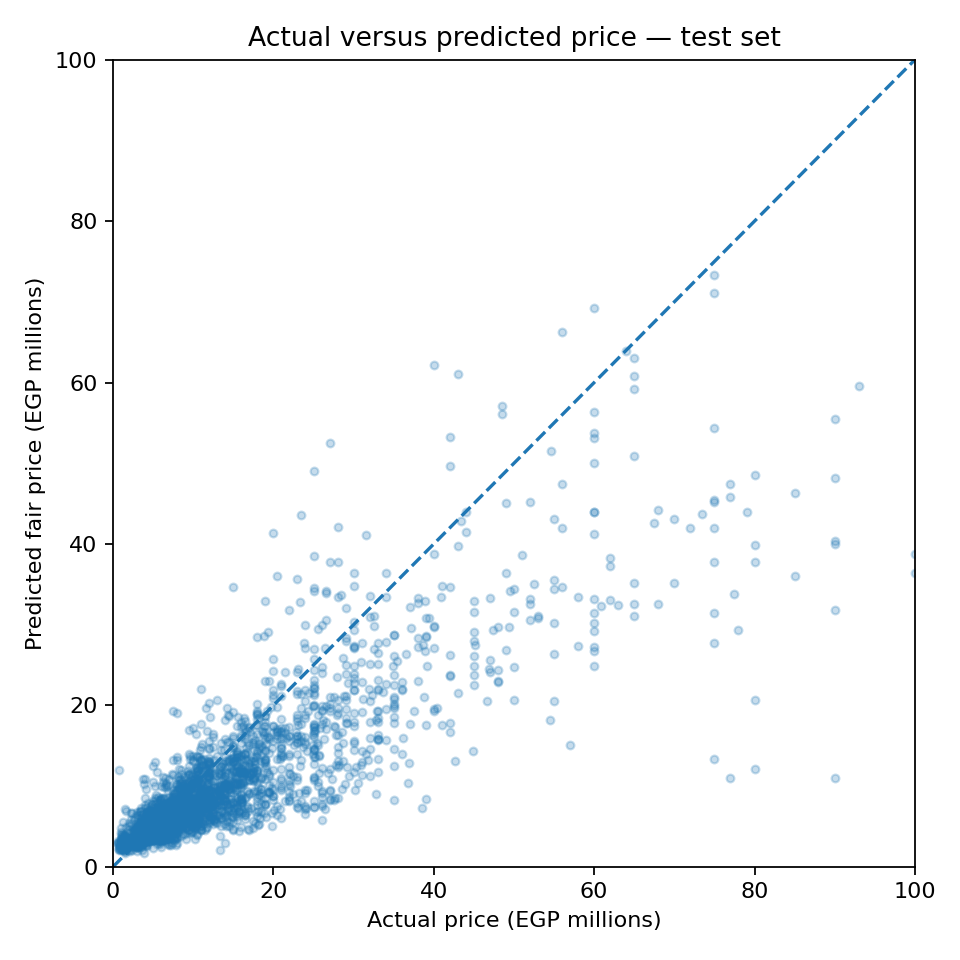

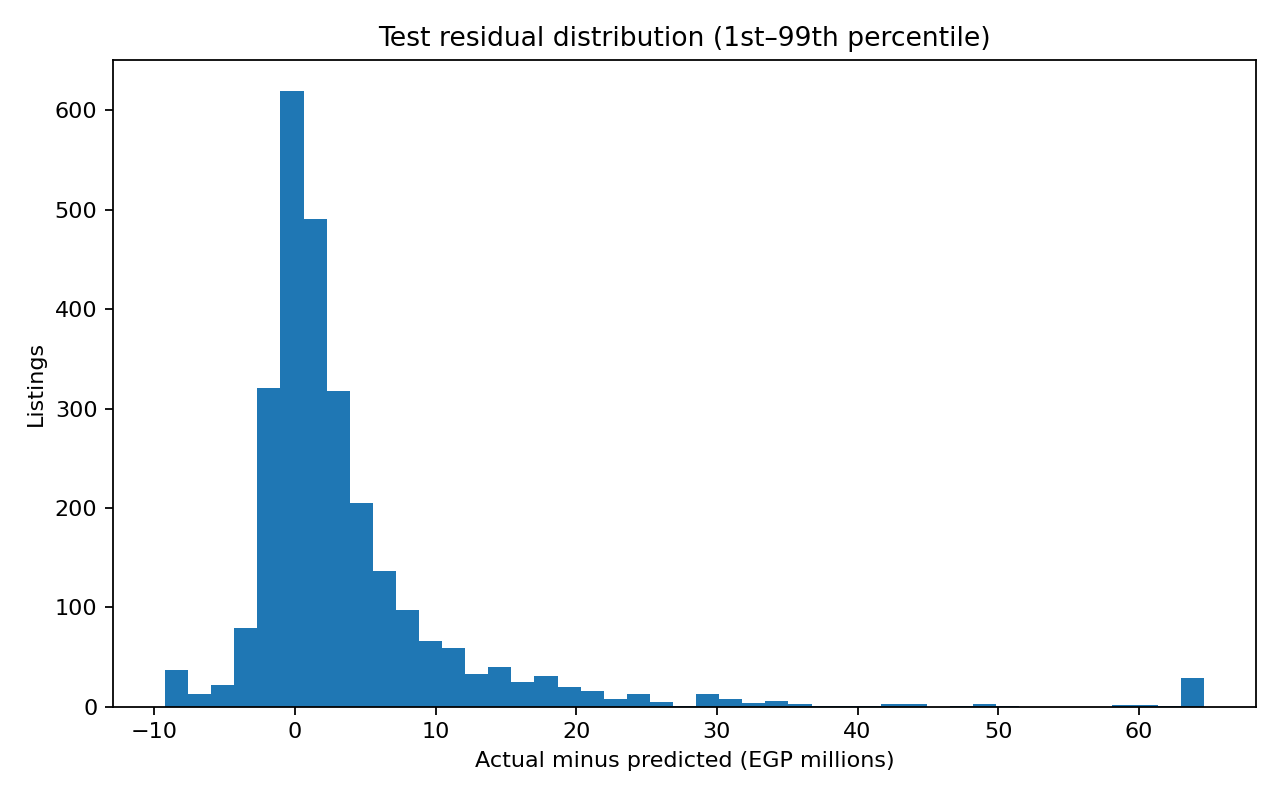

In [12]:
display(pd.Series(meta["test_metrics"], name="test metric").to_frame())
test = pd.read_parquet(ROOT / "reports/tables/test_predictions.parquet")
display(test.sort_values("absolute_error", ascending=False).head(10))
display(Image(filename=str(ROOT / "reports/figures/model_actual_vs_predicted.png")))
display(Image(filename=str(ROOT / "reports/figures/residual_distribution.png")))

## 9. Error analysis by segment

Segment metrics expose where the model is weak. Small groups should not be interpreted as stable performance estimates.

In [13]:
for name in ["error_by_property_type.csv", "error_by_market_region.csv", "error_by_market_tier.csv", "error_by_town.csv"]:
    print(name)
    display(pd.read_csv(ROOT / "reports/tables" / name).head(20))

error_by_property_type.csv


,property_type,sample_size,mae_egp,median_ae_egp,mape
0,Apartment,1496,2.553516e+06,1.453319e+06,0.297782
1,Villa,450,1.762644e+07,8.231739e+06,0.423906
2,Chalet,343,4.708913e+06,2.059994e+06,0.405882
3,Townhouse,245,5.042441e+06,3.370135e+06,0.403032
4,Duplex,103,4.372573e+06,3.229069e+06,0.361314
5,Twin House,102,8.126022e+06,5.061126e+06,0.273804


error_by_market_region.csv


,market_region,sample_size,mae_egp,median_ae_egp,mape
0,Cairo,1199,5.213232e+06,2.299300e+06,0.324578
1,Giza,882,3.883446e+06,2.039099e+06,0.333595
2,North Coast,423,1.344722e+07,4.460057e+06,0.421205
3,Alexandria,88,2.069397e+06,1.352215e+06,0.229714
4,Suez,77,2.389878e+06,1.924042e+06,0.592583
5,Red Sea,63,2.299466e+06,6.420524e+05,0.152420
6,Qalyubia,7,9.582215e+05,1.047563e+06,0.332592


error_by_market_tier.csv


,market_tier,sample_size,mae_egp,median_ae_egp,mape
0,Mid-market,758,1.863448e+06,1.264367e+06,0.203647
1,Upper-mid,753,4.138562e+06,3.073117e+06,0.259578
2,Luxury,651,1.583900e+07,9.046016e+06,0.451402
3,Affordable,577,1.805413e+06,1.108547e+06,0.512397


error_by_town.csv


,town,sample_size,mae_egp,median_ae_egp,mape
0,New Cairo City,525,5.138109e+06,3.236836e+06,0.295209
1,6 October City,507,3.884584e+06,2.153181e+06,0.347463
2,Sheikh Zayed City,358,4.030061e+06,2.015239e+06,0.319861
3,Sidi Abdel Rahman,263,2.001095e+07,1.097603e+07,0.455691
4,Madinaty,257,7.995158e+06,2.700799e+06,0.335427
5,Mostakbal City - Future City,199,1.166487e+06,8.128444e+05,0.433090
6,Ras Al Hekma,90,2.946828e+06,1.929989e+06,0.299544
7,Al Ain Al Sokhna,77,2.389878e+06,1.924042e+06,0.592583
8,New Capital City,75,1.822223e+06,1.170616e+06,0.209939
9,Al Alamein,68,1.112340e+06,9.808034e+05,0.421551


## 10. Explainability

SHAP values describe how features influence predictions within this model. They are predictive associations, not causal effects.

,feature,mean_abs_shap_log_price
0,area_sqm,0.230865
1,property_type,0.184435
2,completion_status,0.118714
3,bathrooms_num,0.092903
4,district,0.077832
5,payment_method,0.073919
6,furnished,0.070135
7,submarket_or_compound,0.053885
8,lon,0.046929
9,bedrooms_per_100_sqm,0.045237


,feature,value,shap_log_price,abs_shap
0,property_type,Apartment,-0.170377,0.170377
1,submarket_or_compound,Mountain View iCity October,-0.131388,0.131388
2,payment_method,installments,0.108860,0.108860
3,furnished,Unknown,-0.106495,0.106495
4,bathrooms_num,2.0,-0.106024,0.106024
5,completion_status,completed,0.104628,0.104628
6,area_sqm,150.0,-0.060793,0.060793
7,listing_age_days,27.9864329703588,-0.057399,0.057399
8,bedrooms_per_100_sqm,2.0,-0.051240,0.051240
9,lat,30.00507354736328,0.047957,0.047957


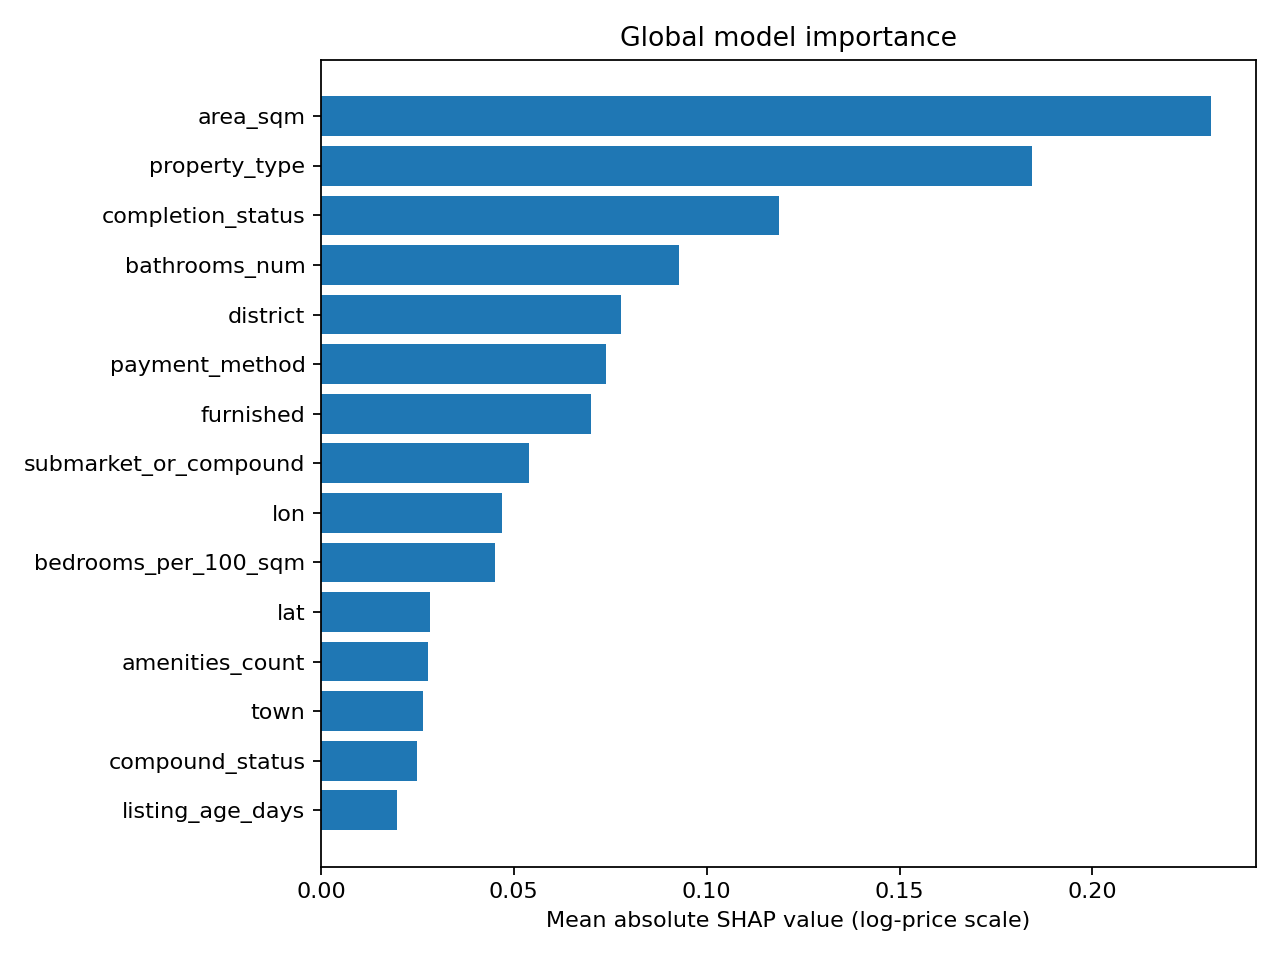

In [14]:
shap_global = pd.read_csv(ROOT / "reports/tables/shap_global_importance.csv")
local = pd.read_csv(ROOT / "reports/tables/example_local_explanation.csv")
display(shap_global.head(20))
display(local.head(15))
display(Image(filename=str(ROOT / "reports/figures/shap_feature_importance.png")))

## 11. Fair-price and opportunity outputs

For each analytical listing, the pipeline exports a predicted fair asking price, validation-calibrated range, under/fair/over classification, model-support count, out-of-distribution flags, and confidence label.

In [15]:
cols=["title","town","property_type","area_sqm","price_egp","predicted_fair_price","lower_fair_price","upper_fair_price","pricing_status","model_confidence"]
display(market[cols].head(20))
print(market["pricing_status"].value_counts())

,title,town,property_type,area_sqm,price_egp,predicted_fair_price,lower_fair_price,upper_fair_price,pricing_status,model_confidence
0,Garden Villa - Lake View Boutique - Prime Loca...,New Cairo City,Duplex,445.0,24500000.0,2.086135e+07,1.079879e+07,5.439062e+07,Fairly priced,High
1,For Sale: Finished Apartment+ ACs in Village West,Sheikh Zayed City,Apartment,123.0,5145000.0,6.903599e+06,3.573620e+06,1.799936e+07,Fairly priced,High
2,UnderMarket Price for Apt. 250 RTM PrimeLocation,New Cairo City,Apartment,250.0,10800000.0,1.394931e+07,7.220804e+06,3.636925e+07,Fairly priced,High
3,lowest price 2bds fullyfurnished @ lake view,New Cairo City,Apartment,136.0,10500000.0,1.276481e+07,6.607652e+06,3.328097e+07,Fairly priced,High
4,Exclusive Type M with Lowest Price RTM in PNC,New Cairo City,Villa,255.0,19500000.0,2.058577e+07,1.065614e+07,5.367212e+07,Fairly priced,High
5,For Sale: 209m Apartment with Garden in Address,Sheikh Zayed City,Apartment,209.0,11750000.0,6.977118e+06,3.611676e+06,1.819105e+07,Fairly priced,High
6,Ready-to-move apt at the lowest price aeon Tower,6 October City,Apartment,285.0,30000000.0,1.935242e+07,1.001770e+07,5.045648e+07,Fairly priced,High
7,Swan Lake Gouna’s Last Unit — Flexible Install...,Hurghada,Apartment,144.0,23250000.0,9.175175e+06,4.749491e+06,2.392191e+07,Fairly priced,High
8,lowest type B villa ready to move at Palm hills,New Cairo City,Villa,963.0,47000000.0,6.012262e+07,3.112223e+07,1.567543e+08,Fairly priced,Medium
9,Twinhouse in Levana with Smart System,El Khalifa,Twin House,320.0,37000000.0,1.764373e+07,9.133201e+06,4.600149e+07,Fairly priced,Low


pricing_status
Fairly priced    17183
Underpriced        656
Overpriced         214
Name: count, dtype: int64


## 12. Dashboard and deployment artifacts

The Streamlit application loads precomputed datasets and the exported CatBoost model; it does not retrain during use. Run it from the project root with:

```bash
streamlit run dashboard/app.py
```

In [16]:
required = [
    ROOT / "dashboard/app.py", ROOT / "models/final_model/catboost_fair_price.cbm",
    ROOT / "data/dashboard/market_listings.parquet", ROOT / "data/dashboard/pricing_opportunities.parquet",
    ROOT / "requirements.txt", ROOT / "README.md"
]
for p in required:
    print("OK" if p.exists() else "MISSING", p.relative_to(ROOT))

OK dashboard/app.py
OK models/final_model/catboost_fair_price.cbm
OK data/dashboard/market_listings.parquet
OK data/dashboard/pricing_opportunities.parquet
OK requirements.txt
OK README.md


## 13. Executive conclusion

The system provides a defensible first-pass asking-price benchmark and market-positioning tool for Egyptian residential sale listings. Its strongest use is comparative market intelligence, campaign segmentation, and anomaly review. It should not replace professional appraisal, verified transaction data, or manual review of unusual listings.

### Limitations and next steps

1. Acquire completed-transaction or reservation data to reduce asking-price bias.
2. Add a verified developer/project registry before developer scoring.
3. Improve geographic entity resolution and add approved coordinates/mappings.
4. Monitor drift and retrain as market conditions change.
5. Collect richer payment-plan, delivery, finishing, floor, and project-age fields.